<a href="https://colab.research.google.com/github/matti410/Trading-System-Creator_V4/blob/main/Trading_System_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trading System Lab
### Dall'idea alla strategia verificata, in sette passi

Scegli tu i segnali di ingresso e le uscite. Lo strumento misura, scarta quello che non regge e ti dice quanto rischio aspettarti.

**Come si usa:** in ogni passo imposta i valori nel riquadro a destra, poi premi il tasto ▶ a sinistra della cella. I passi vanno eseguiti in ordine, dall'alto verso il basso.

## Avvio
Da eseguire una volta sola, all'inizio. Richiede circa un minuto.

In [12]:
#@title Avvio { display-mode: "form" }
import os, shutil, subprocess, sys, warnings
warnings.simplefilter("ignore")

REPO = "matti410/Trading-System-Creator_V4"
CARTELLA = "/content/Trading-System-Creator_V4"

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "TA-Lib==0.8.1", "backtesting==0.6.6"], check=True)

# Il token di GitHub si legge dai Secrets di Colab (icona della chiave, a sinistra):
# non va mai scritto qui dentro. Senza token si prova il repo pubblico.
token = None
try:
    from google.colab import userdata
    token = userdata.get("GITHUB_TOKEN")
except Exception:
    pass

os.chdir("/content")
shutil.rmtree(CARTELLA, ignore_errors=True)
indirizzo = f"https://{token}@github.com/{REPO}.git" if token else f"https://github.com/{REPO}.git"
esito = subprocess.run(["git", "clone", "--quiet", "--depth", "1", indirizzo, CARTELLA], capture_output=True, text=True)
if esito.returncode != 0:
    raise RuntimeError("Non riesco a scaricare il progetto da GitHub. Se il repo è privato, controlla che il "
                       "secret GITHUB_TOKEN esista e che l'accesso dal notebook sia attivo.")

os.chdir(CARTELLA)
if CARTELLA not in sys.path:
    sys.path.insert(0, CARTELLA)
for nome in [m for m in sys.modules if m == "engine" or m.startswith("engine.")]:
    del sys.modules[nome]

%matplotlib inline
from IPython.utils.capture import capture_output
with capture_output():      # le librerie stampano avvisi tecnici al primo caricamento
    from engine.vetrina import (prepara, esplora, classifiche, scegli_trigger,
                                imposta_uscite, trova_strategia, scheda,
                                verifica_trade, lente, stress_test)
print("Pronto.")

Pronto.


## 1 · Configura
Scegli lo strumento e per quante barre osservare il prezzo dopo ogni segnale (1 barra = 15 minuti).

In [13]:
#@title 1 · Configura { display-mode: "form" }
strumento = "BTCUSD"  #@param ["EURUSD", "BTCUSD"]
orizzonte = 25  #@param {type:"slider", min:4, max:96, step:1}

s = prepara(strumento, H=orizzonte)

,
Strumento,BTCUSD
Barre M15,221.308
Periodo,07/01/2020 – 19/09/2026
In-sample (per costruire),"177.046 barre, fino al 11/06/2025"
Out-of-sample (mai visto),"44.262 barre, dal 11/06/2025"
Costo per trade,"10,54 pips di spread, nessuna commissione (dati storici (75° percentile))"
Costo nel rollover,"11,61 pips"
Orizzonte di osservazione,"25 barre (6,2 ore)"
Trigger disponibili,32 long · 32 short
Filtri disponibili,37


## 2 · Esplora
Cosa fa il prezzo dopo ogni segnale di ingresso?

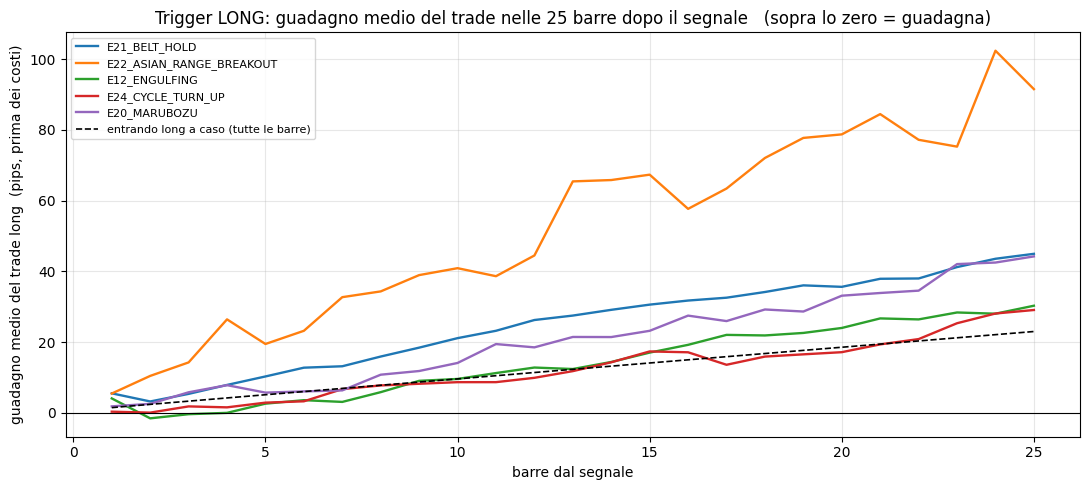

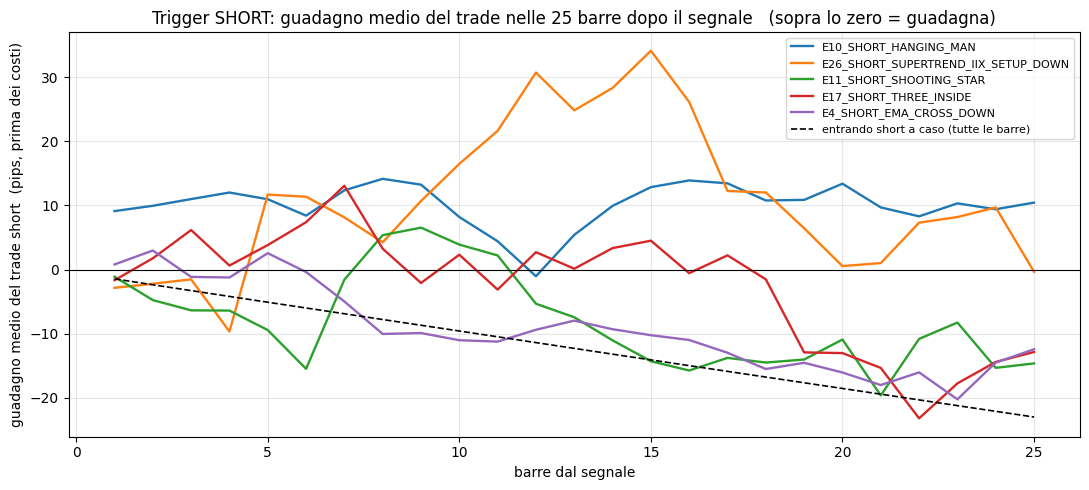

In [14]:
#@title 2 · Esplora { display-mode: "form" }
esplora(s);

## 3 · Scegli i trigger
Le due classifiche, e poi la tua scelta.

In [15]:
#@title 3a · Le classifiche { display-mode: "form" }
classifiche(s);

Trigger,Movimento a favore (pips),Dopo quante barre,Occasioni,Solidità del segnale,Supera il rumore
E21_BELT_HOLD,"44,43",25,12.156,"4,93",sì
E22_ASIAN_RANGE_BREAKOUT,"104,33",24,812,"3,54",no
E12_ENGULFING,"29,63",25,14.671,"3,49",no
E24_CYCLE_TURN_UP,"28,97",25,10.153,"3,33",no
E20_MARUBOZU,"44,55",25,3.740,"3,26",no
E3_LONG_INTRABAR_WEAKNESS_FADE,"39,77",25,7.755,"3,25",no
E21_BELT_HOLD_CONFIRMED,"34,62",23,5.804,"3,10",no
E8_CLOSING_PATTERN_ONLY,"32,04",25,7.265,"2,95",no
Trigger,Movimento a favore (pips),Dopo quante barre,Occasioni,Solidità del segnale,Supera il rumore
E10_SHORT_HANGING_MAN,"13,81",8,2.333,"1,62",no


In [16]:
#@title 3b · La tua scelta { display-mode: "form" }
#@markdown Copia i nomi dalla classifica. Più nomi sullo stesso lato: separali con una virgola. Lato vuoto = spento.
trigger_long = "E21_BELT_HOLD, E22_ASIAN_RANGE_BREAKOUT"  #@param {type:"string"}
trigger_short = ""  #@param {type:"string"}

scegli_trigger(s, long=trigger_long, short=trigger_short)

Lato,Trigger scelti
LONG,E21_BELT_HOLD oppure E22_ASIAN_RANGE_BREAKOUT
SHORT,nessuno (lato spento)


## 4 · Imposta le uscite
Dopo quante barre chiudere, e quanto larghi tenere stop e target.

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Sistema,Trade,Guadagno medio netto per trade (pips),Trade vincenti (%),Solidità,Durata media (barre)
Solo long,4.718,"9,52","48,73","0,88","23,6"


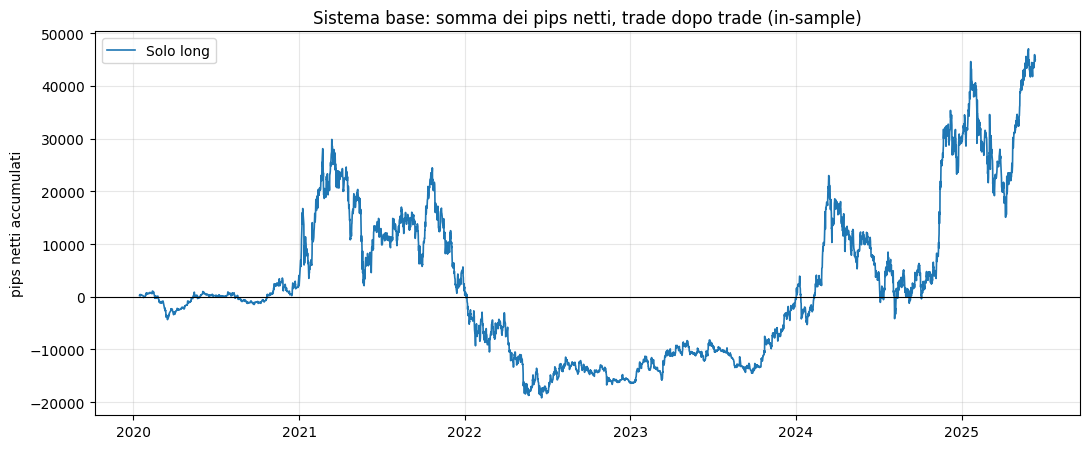

In [17]:
#@title 4 · Imposta le uscite { display-mode: "form" }
#@markdown Uscita a tempo, in barre (può essere diversa fra long e short)
barre_long = 25  #@param {type:"slider", min:1, max:96, step:1}
barre_short = 25  #@param {type:"slider", min:1, max:96, step:1}
#@markdown Stop e target adattivi, come percentile (0 = spento)
stop = 90  #@param {type:"slider", min:0, max:99, step:1}
target = 0  #@param {type:"slider", min:0, max:99, step:1}

imposta_uscite(s, barre_long=barre_long, barre_short=barre_short, sl=stop, tp=target);

## 5 · Trova la strategia
Lo strumento prova tutti i filtri disponibili sul tuo sistema base. Richiede circa mezzo minuto.

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

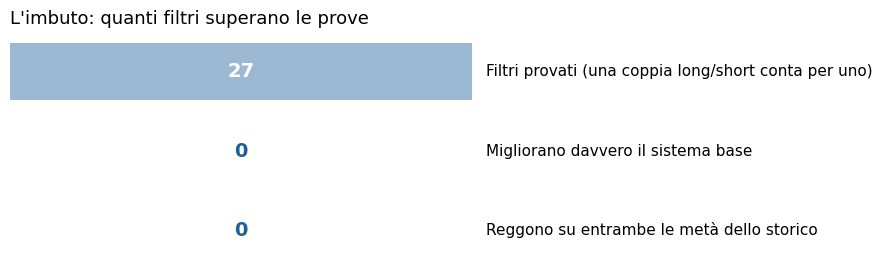

Filtro,Trade,Guadagno medio netto per trade (pips),Miglioramento sul sistema base (pips),Solidità del miglioramento,Prima prova,Seconda prova (due metà)
Sistema base (nessun filtro),4.718,"9,52",—,—,—,—
F3_VOLUME_ABOVE_AVG,3.352,"17,91","39,68","1,82",non passa: miglioramento sotto l'asticella,—
F6_VOLUME_ABOVE_AVG_50,3.179,"25,17","35,85","1,64",non passa: miglioramento sotto l'asticella,—
F8_UPTREND_CONTEXT,3.457,"16,25","29,58","1,32",non passa: miglioramento sotto l'asticella,—
F20_SESSION_US,1.628,"12,92","29,04","1,13",non passa: miglioramento sotto l'asticella,—
F10_TREND_CONVICTION_UP,1.980,"25,89","20,90","0,93",non passa: miglioramento sotto l'asticella,—
F14_LOW_DRIFT_REGIME,1.704,"16,03","21,15","0,91",non passa: miglioramento sotto l'asticella,—
F7_VOLUME_CLIMAX,1.306,"21,80","29,19","0,81",non passa: miglioramento sotto l'asticella,—
F21_OVERNIGHT_UP,2.592,"12,27","17,55","0,80",non passa: miglioramento sotto l'asticella,—


In [18]:
#@title 5 · Trova la strategia { display-mode: "form" }
trova_strategia(s);

## 6 · Scheda strategia
La prova sui dati che la strategia non ha mai visto.

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177045 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/44261 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/44261 [00:00<?, ?bar/s]

Passo,Trade,Guadagno medio netto per trade (pips),Miglioramento sul passo prima (pips),Solidità del miglioramento
Sistema base,4.718,"9,52",—,—
+ F6_VOLUME_ABOVE_AVG_50,3.179,"25,17","35,85","1,64"
+ F2_HIGH_VOLATILITY,1.159,"34,59","9,67","0,27"


,In-sample,Out-of-sample
Trade,1.159,314
Guadagno medio netto per trade (pips),"34,59","-39,14"
Totale pips netti,40.095,-12.291
Trade vincenti (%),"50,0","49,7"
Vincenti necessari per il pareggio (%),"47,0","52,1"
Vincita media / perdita media,"1,13","0,92"
Profit factor,"1,12","0,91"
Solidità,"1,25","-0,64"
Probabilità che in realtà perda (%),"10,5","73,8"
Drawdown massimo (pips),13.651,37.375


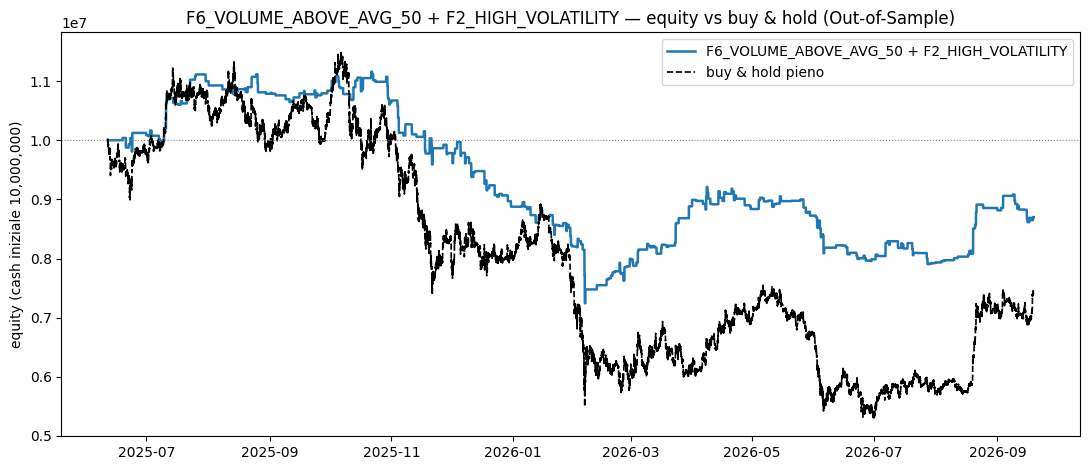

In [19]:
#@title 6 · Scheda strategia { display-mode: "form" }
#@markdown Uno o più filtri copiati dalla classifica, separati da virgola: si entra solo quando sono veri tutti. Vuoto = sistema base, senza filtro.
filtro = "F6_VOLUME_ABOVE_AVG_50, F2_HIGH_VOLATILITY"  #@param {type:"string"}

scheda(s, filtro=filtro);

## 7 · Verifica i trade
Il backtest è entrato davvero dove dicono le tue regole?

In [20]:
#@title 7a · Controllo automatico { display-mode: "form" }
verifica_trade(s);

Regola,Rispettata in,Esito,Trade da guardare
Il trigger era vero sulla barra prima dell'ingresso,1.473 trade su 1.473,OK,—
Tutti i filtri scelti erano veri su quella barra,1.473 trade su 1.473,OK,—
L'ingresso è all'apertura della barra dopo il segnale,1.473 trade su 1.473,OK,—
Né il segnale né l'ingresso cadono nel rollover,1.473 trade su 1.473,OK,—
Il trade non dura più delle barre del suo lato,1.473 trade su 1.473,OK,—
Una posizione alla volta,1.473 trade su 1.473,OK,—
Ogni segnale non tradato ha un motivo,16.976 segnali su 16.976,OK,—


Uscita per,In-sample,Out-of-sample
a tempo,933,253
stop,226,61
Che fine ha fatto il segnale,In-sample,Out-of-sample
è diventato un trade,1.159,314
posizione già aperta nello stesso verso,680,205
filtro falso,11.723,2.823
barra nel rollover o dopo una pausa,59,11
stop non ancora calcolabile (avvio dello storico),0,1
trade ancora aperto a fine storico,1,0


In [21]:
#@title 7b · La lente sul trade { display-mode: "form" }
periodo = "out-of-sample"  #@param ["out-of-sample", "in-sample"]
#@markdown Numero del trade (0 = uno a caso), oppure una data: apre il primo trade da quel giorno.
numero = 201  #@param {type:"integer"}
data = ""  #@param {type:"string"}
#@markdown Indicatori da disegnare, separati da virgola (l'elenco di quelli disponibili è sotto il grafico).
indicatori = "rsi"  #@param {type:"string"}
#@markdown Disegna anche la regola dei trigger scattati: nome, candele della figura, livello rotto, indicatori che la regola legge.
mostra_trigger = True  #@param {type:"boolean"}
barre_prima = 40  #@param {type:"slider", min:10, max:200, step:5}
barre_dopo = 25  #@param {type:"slider", min:5, max:200, step:5}

lente(s, periodo=periodo, numero=numero, data=data, indicatori=indicatori,
      barre_prima=barre_prima, barre_dopo=barre_dopo, mostra_trigger=mostra_trigger);

,
Trade,n. 201 di 314 · LONG · out-of-sample
Trigger scattato,E21_BELT_HOLD
Filtri veri sul segnale,"F6_VOLUME_ABOVE_AVG_50, F2_HIGH_VOLATILITY"
Segnale (sulla candela delle),24/03/2026 21:15
Ingresso (all'apertura della candela delle),24/03/2026 21:30 a 69981.0
Uscita,25/03/2026 03:45 a 70656.4 · a tempo
Risultato,+675.5 pips netti


## 8 · Stress test
Quanto drawdown aspettarsi, e con quanti lotti partire.

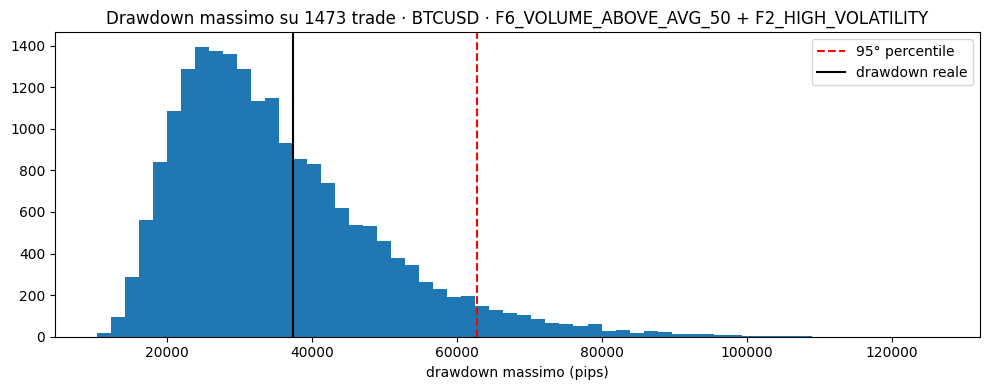

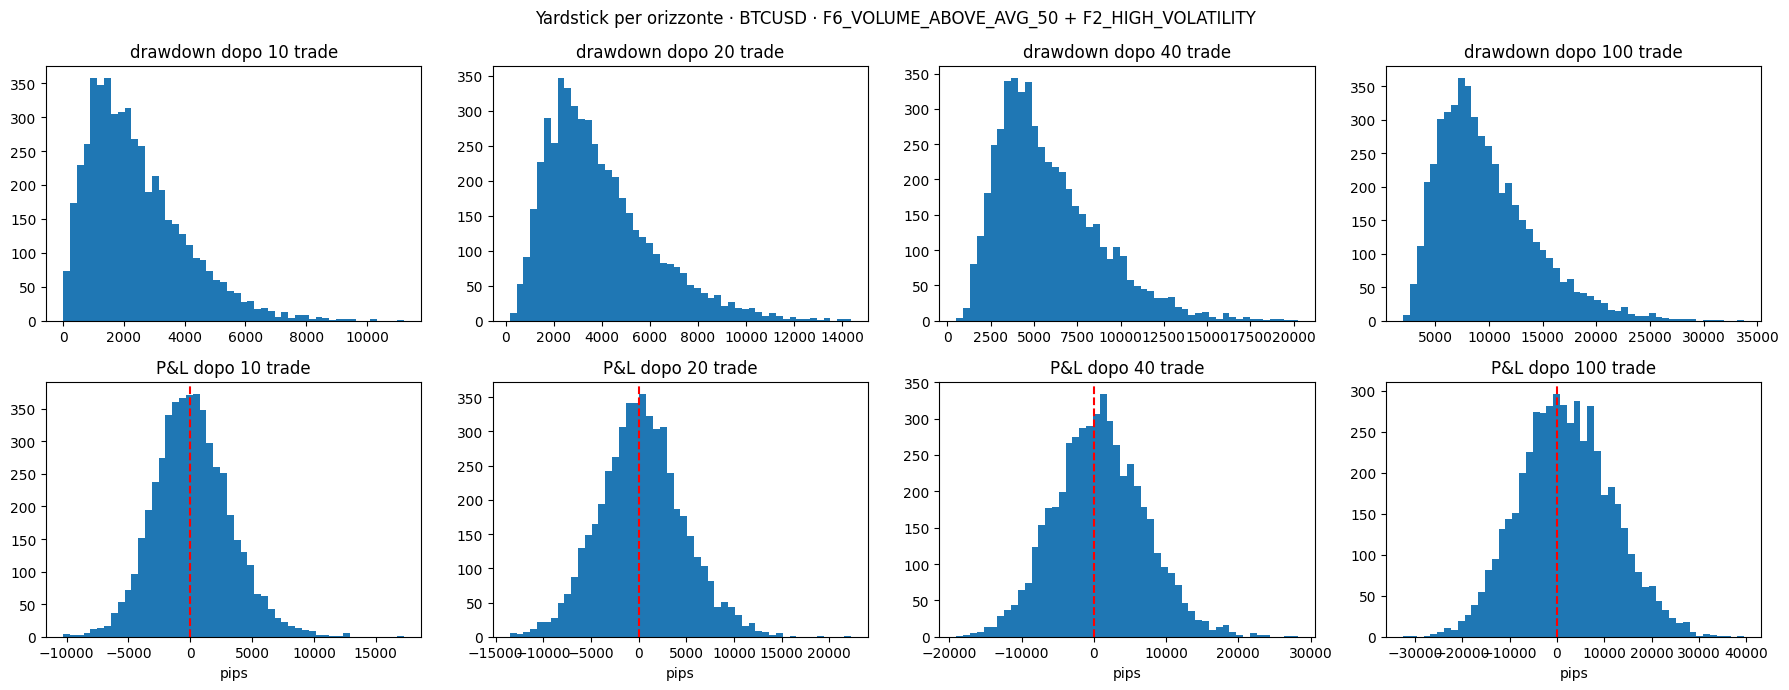

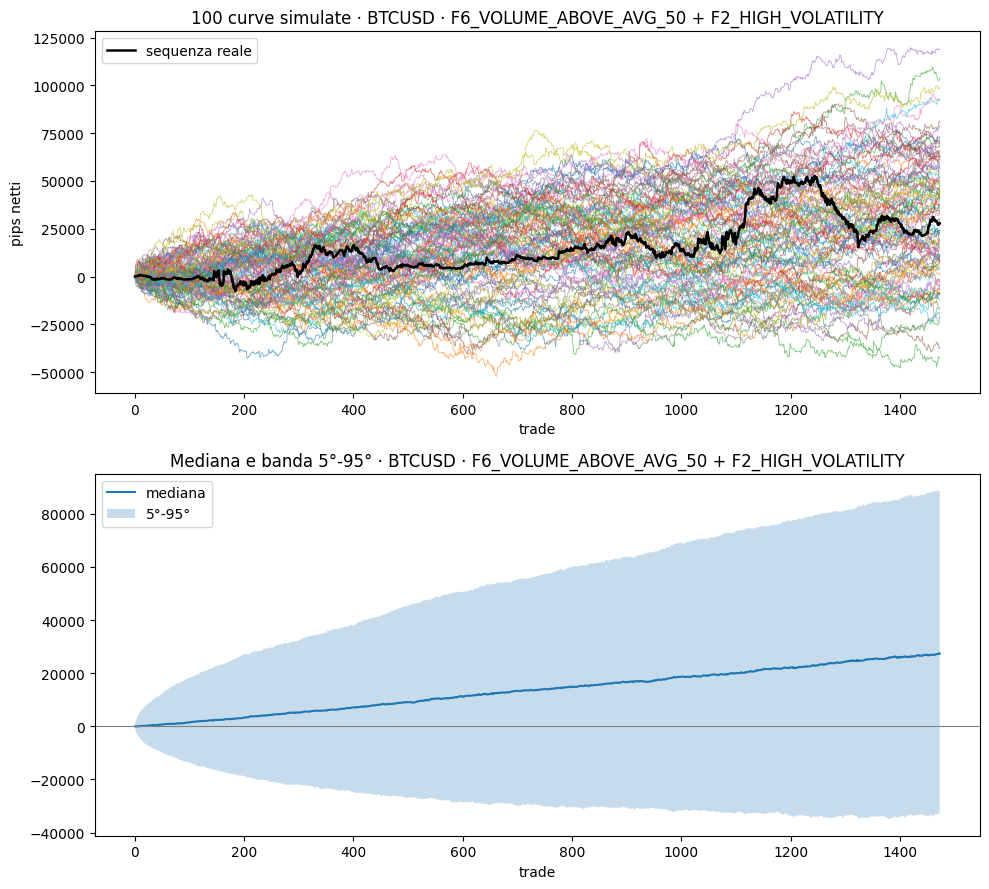

In [22]:
#@title 8 · Stress test { display-mode: "form" }
drawdown_massimo_in_dollari = 10000  #@param {type:"number"}

stress_test(s, drawdown_max_usd=drawdown_massimo_in_dollari);